# Cyber Data Science Project: Statistical analysis & anomaly detection on military-style network traffic.
## by Benjamin Jiles, Cyber Threat Analyst
**Goal:** Demonstrate hypothesis testing, anomaly detection modeling, and customer-facing insights.
This notebook uses simulated **Air Force LAN** dataset to show how to quickly analyze new data feeds, find hidden patterns, and turn them into automated detections.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("All libraries successfully loaded.")

All libraries successfully loaded.


In [7]:
# columns = [
#    "duration",  "protocol_type",  "service",  "flag",  "src_bytes",  "dst_bytes",  "land",  "wrong_fragment",  "urgent",  "hot",  "num_failed_logins",  "logged_in",  "num_compromised",  "root_shell",  "su_attempted",  "num_root",  "num_file_creations",  "num_shells",  "num_access_files",  "num_outbound_cmds",  "is_host_login",  "is_guest_login",  "count",  "srv_count",  "serror_rate",  "srv_serror_rate",  "rerror_rate",  "srv_rerror_rate",  "same_srv_rate",  "diff_srv_rate",  "srv_diff_host_rate",  "dst_host_count",  "dst_host_srv_count",  "dst_host_same_srv_rate",  "dst_host_diff_srv_rate",  "dst_host_same_src_port_rate",  "dst_host_srv_diff_host_rate",  "dst_host_serror_rate",  "dst_host_srv_serror_rate",  "dst_host_rerror_rate",  "dst_host_srv_rerror_rate",  "class"
# ]

df = pd.read_csv("Train_data.csv", names=columns, header=0)

print("Dataset loaded.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded.
Shape: (25192, 42)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [8]:
# Basic exploration
print("Class distribution:")
print(df['class'].value_counts().head(10))

# Create binary attack flag (normal vs everything else)
df['is_attack'] = df['class'] != 'normal'
print("\nNormal vs Attack:")
print(df['is_attack'].value_counts())

Class distribution:
class
normal     13449
anomaly    11743
Name: count, dtype: int64

Normal vs Attack:
is_attack
False    13449
True     11743
Name: count, dtype: int64


In [9]:
# Hypothesis test example: is packet duration sig diff between normal and attack traffic?
normal_duration = df[df['is_attack'] == False]['duration']
attack_duration = df[df['is_attack'] == True]['duration']

t_stat, p_value = stats.ttest_ind(normal_duration, attack_duration, equal_var=False)

print("Hypothesis Test: Difference in 'duration' (Normal vs Attack)")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Yes, sig diff. Meaning, packet duration IS a useful detection logic.")
else:
    print("No sig diff. Meaning, packet duration IS NOT a useful detection logic.")

Hypothesis Test: Difference in 'duration' (Normal vs Attack)
t-statistic: -7.6761
p-value: 0.0000
Yes, sig diff. Meaning, packet duration IS a useful detection logic.


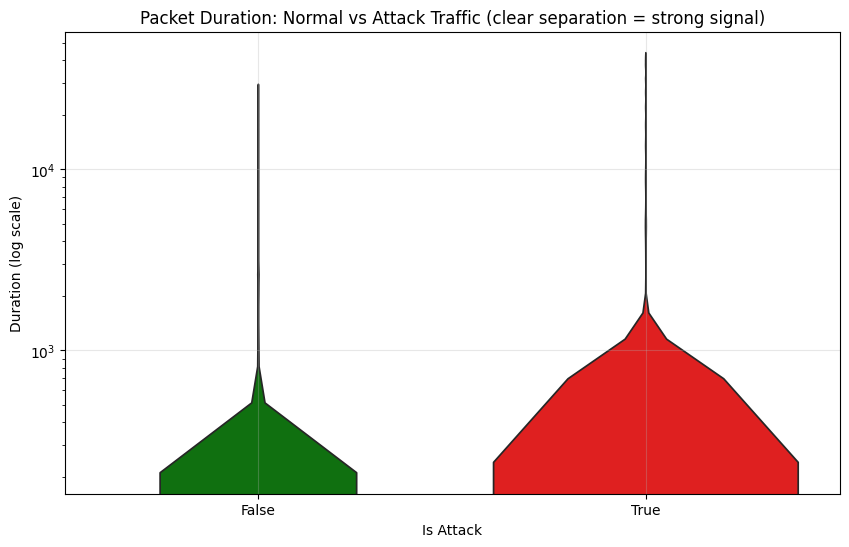

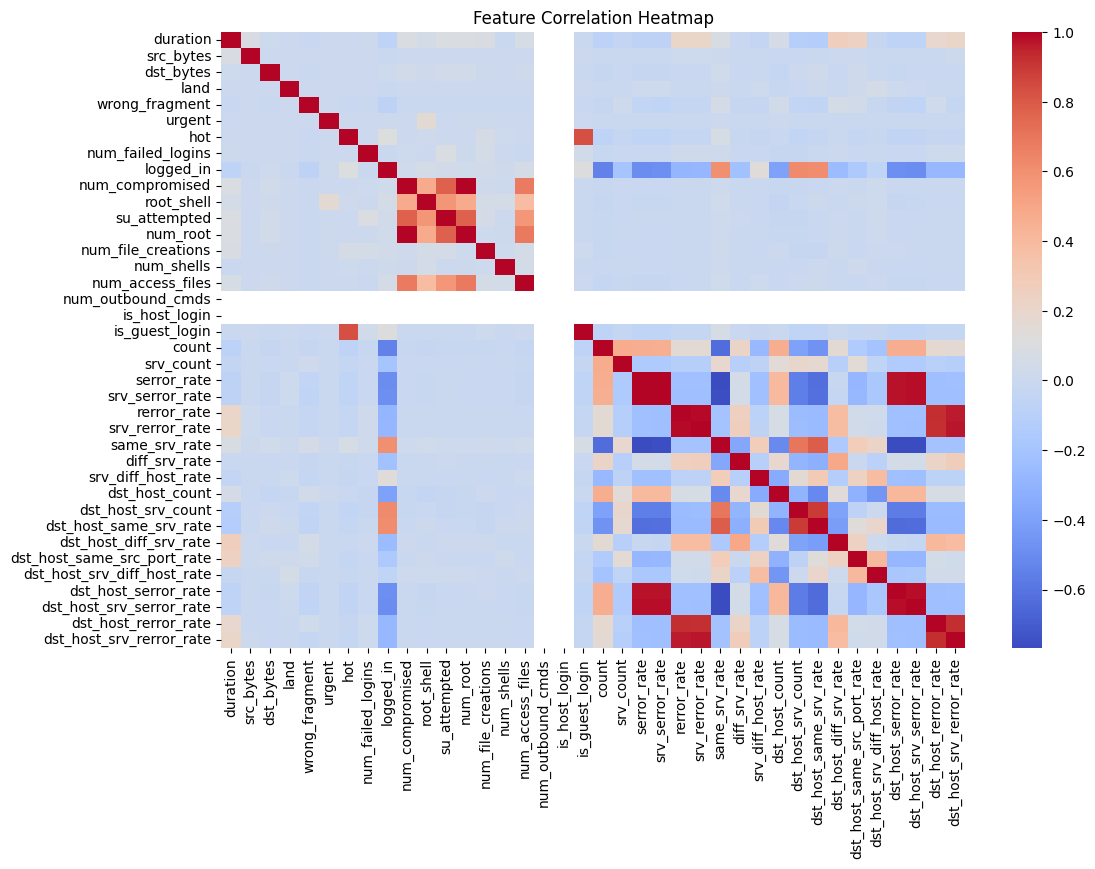

In [14]:
# 1. Boxplot: Duration by Normal vs Attack
plt.figure(figsize=(10, 6))
sns.violinplot(x='is_attack', y='duration', data=df, palette=['green', 'red'], inner='quartile')
plt.yscale('log')
plt.title('Packet Duration: Normal vs Attack Traffic (clear separation = strong signal)')
plt.ylabel('Duration (log scale)')
plt.xlabel('Is Attack')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['is_attack'], errors='ignore')
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

We can see in the **Packet Duration** violin plot that most packet sessions associated with an attack are >800ms. Also, that there may be varying attacks since there are still a lot 0ms packet sessions via attackers. Possibly, both C2 traffic (longer) and scan probes (0ms).

In the **Correlation Heatmap** we see that a compromised machine with malicious traffic, correlates highly with: number of root shells running, su command attempts, number of root users, the number of files accessed, and when guest login is detected. This looks like classic privilege escalation TTPs.

In [15]:
# Select features for modeling
features = numeric_df.columns.tolist()
X = numeric_df[features].fillna(0)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train isolation forest (unsupervised anomaly detection)
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X_scaled)

# Predict anomalies (-1 = anomaly, 1 = normal)
df['anomaly_score'] = model.predict(X_scaled)

print("Anomaly detection results:")
print(df['anomaly_score'].value_counts())
print(f"Detected { (df['anomaly_score'] == -1).sum() } potential anomalies")

Anomaly detection results:
anomaly_score
 1    22672
-1     2520
Name: count, dtype: int64
Detected 2520 potential anomalies


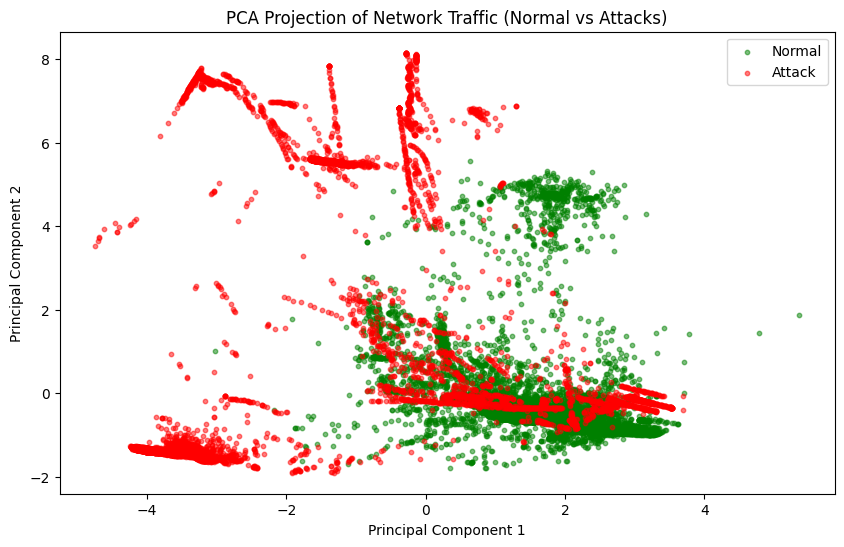

In [16]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[df['is_attack'] == False, 0], X_pca[df['is_attack'] == False, 1],
            c='green', label='Normal', alpha=0.5, s=10)
plt.scatter(X_pca[df['is_attack'] == True, 0], X_pca[df['is_attack'] == True, 1],
            c='red', label='Attack', alpha=0.5, s=10)
plt.title('PCA Projection of Network Traffic (Normal vs Attacks)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

The PCA projection shows that there are large, clear distinct network packet patterns that differ enough from Normal traffic, which is useful for detection (Attack traffic from PC1 -4 to -2 on PC2 -1; and Attack traffic above PC2 4 from PC1 -5 to 1). There will be Attack traffic blending in to Normal traffic, which may require further isolation.

## Key Insights & How I Would Apply This as Actionable Intelligence

- **Packet Duration (Violin Plot):** Most attack-related sessions show durations >800 ms, while normal traffic is overwhelmingly 0 ms. The presence of many 0 ms attack sessions suggests a mix of **C2 beaconing (long-duration)** and **scan/probe activity (near-zero duration)**. This is a strong, immediately actionable signal for detection.

- **PCA Projection:** Clear separation between normal and attack traffic is visible in the 2D space (attack clusters at PC1: -4 to -2 on PC2 ≈ -1, and another cluster with PC2 > 4 and PC1: -5 to 1). Some attack traffic blends into the normal cluster, indicating the need for additional features or multi-layer isolation to reduce false negatives.

- **Correlation Heatmap:** Malicious traffic shows strong positive correlation with privilege-escalation indicators: number of root shells, `su` command attempts, number of root users, number of files accessed, and guest logins. These map directly to classic **MITRE ATT&CK privilege escalation TTPs** (T1548, T1552, T1134, etc.).

**Customer Recommendation:**
I would immediately translate these findings into:
- KQL analytics in Microsoft Sentinel/Defender XDR (duration > 800 ms + root-shell activity)
- Automated indicator enrichment (similar to the Python VirusTotal tool I built previously)
- New detection playbooks that flag blended traffic for deeper threat hunting

This type of rapid statistical + visual analysis would reduce false positives and give threat hunters and customers clear, actionable intelligence on the platform.